# 3 · Tides

The waterline method (pages 5–6) does not measure elevation directly. It asks, for each
pixel: *at what tide height does this spot switch from wet to dry?* That crossover
height **is** the elevation — but only if you have satellite images taken when the sea
was **high**, **low**, and everywhere in between.

This notebook is a **feasibility check** before you commit to downloading imagery. It
combines two independent sources:

- **FES2022** — a global harmonic tide model that tells us what the sea level *should*
  have been at every moment in your time window.
- **Planetary Computer** — the catalogue of when Landsat and Sentinel-2 actually flew
  over your site, and whether each scene was clear enough to use.

The question is not “are there satellites?” but “do those overpasses **sample the tidal
cycle** well enough?” A sun-synchronous orbit returns to the same place at roughly the
same local time every 8–16 days. That regularity is convenient for land monitoring, but
it can **miss** parts of the tide curve — a phenomenon called **tidal aliasing**. If
every Landsat pass happens near mid-tide, you will never see the lowest flats dry.

This notebook answers three questions for your site:

1. What is the **tidal range** here (FES2022)?
2. When do **Landsat** and/or **Sentinel-2** actually overpass, and at what tide height?
3. Does that sampling **cover the tidal cycle** well enough for mapping?

**How to read the results**

| Metric | Meaning |
|---|---|
| **HAT / LAT** | Highest / lowest astronomical tide in the model period |
| **HOT / LOT** | Highest / lowest tide height at which a clear satellite scene was acquired |
| **HAT offset** | Gap between HAT and HOT — high water never observed by satellites |
| **LAT offset** | Gap between LAT and LOT — low water never observed |
| **TOT** | Fraction of the full tidal range sampled by satellites (1.0 = perfect) |

Rule of thumb before running page 6:

- **TOT ≥ 0.8** — good range coverage
- **HOT & LOT ≥ 0.5** — acceptable high/low sampling
- **≥ 20 clear scenes** per sensor — stable fit

Run the cells top to bottom. Edit the configuration cell once for your site; the rest
is analysis and plots. Nothing here downloads satellite pixels — only tide model output
and scene metadata.

**Previous:** [2 · Connect](02_connect.ipynb) · **Next:** [4 · Validation](04_validation.ipynb)

## Step 1 - Imports

We load the usual scientific stack plus two project helpers from `cache_utils.py`:

- **`load_or_compute_tides`** — builds (or reloads) the 30-minute FES2022 series for
  your coordinates and date window.
- **`load_or_compute_scenes`** — queries Planetary Computer for scene metadata and tags
  each acquisition with the nearest modelled tide height.
- **`tidal_coverage_stats`** — compares observed scene tides against the full FES2022
  signal (metrics from Bishop-Taylor et al. 2019).

Both expensive steps write **Parquet** files under `cache/`. A second run with the same
site and dates is near-instant unless you set `OVERWRITE = True`.

In [ ]:
import sys
assert sys.version_info >= (3, 12), f"Python >= 3.12 required (have {sys.version.split()[0]})"

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# cache_utils wraps the expensive steps (FES2022 + Planetary Computer).
# Results are saved as Parquet files in cache/ and reloaded on subsequent runs.
from cache_utils import load_or_compute_tides, load_or_compute_scenes, tidal_coverage_stats

warnings.filterwarnings("ignore")

# All saved figures and tables go into outputs/
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Imports OK.")

## Step 2 - Configuration

Everything downstream depends on this cell. Set **`LON`**, **`LAT`**, and
**`SITE_NAME`** to your intertidal area of interest — a point near the centre of the
flat is enough; FES2022 and the STAC search use it as the reference location.

**`TIDE_DIR`** must point to the folder that contains `fes2022b/` (see [1 · Setup](01_setup.md),
Step 5). If FES2022 is missing or mis-located, the tide step will fail before any
satellite query runs.

**Getting FES2022**

| Route | Who | Notes |
|---|---|---|
| **Course / NCK** | [Tim Grandjean](mailto:tim.grandjean@nioz.nl) | Pre-packaged `tide_models/` folder; no AVISO registration |
| **Self-service** | [AVISO+ / CNES](https://www.aviso.altimetry.fr/en/data/products/auxiliary-products/global-tide-fes.html) | Free registration; download FES2022b ocean tide constituents |

Unpack so that `TIDE_DIR` (default `./tide_models`) contains `fes2022b/ocean_tide_20241025/*.nc`.

**`START`** and **`END`** define the analysis window. One calendar year is fine for
exploring the method; **three or more years** is better for feasibility, because tidal
aliasing depends on how satellite revisit lines up with the spring–neap cycle over time.
If coverage looks poor for 2023 alone, extend the dates before giving up on the site.

Choose which sensors to include. This affects every plot and table in the notebook — it
does **not** download imagery yet, only counts what *would* be available:

| Sensor | Revisit | Resolution | Notes |
|---|---|---|---|
| **Sentinel-2** | ~5 days | 10 m | Denser sampling; data from 2015 |
| **Landsat 8 / 9** | ~16 days each | 30 m | Long archive; two platforms ≈ 8-day combined |

For Dutch Wadden sites, **Landsat 8 + 9** alone often give a workable picture; adding
**Sentinel-2** fills gaps between Landsat passes and improves TOT. Page 6 uses Landsat
only, but checking S2 here still helps you judge whether the site is mappable in general.

**`MAX_CLOUD`** is a scene-level filter (%). Lower values mean fewer but clearer scenes;
raising it adds passes at the cost of more cloud contamination in later notebooks.

Set **`OVERWRITE = True`** once after changing location, dates, or sensors — this
rebuilds the cache. Set back to **`False`** for faster re-runs.

In [7]:
# === EDIT THESE ===
LON        = 4.81050
LAT        = 52.98886
SITE_NAME  = "WaddenSea"

TIDE_DIR   = "./tide_models"   # folder containing fes2022b/ocean_tide_20241025/
TIDE_MODEL = "FES2022"

START = "2023-01-01"
END   = "2023-12-31"

# Toggle sensors on/off — affects both the Planetary Computer query and all plots
USE_SENTINEL2 = True
USE_LANDSAT8  = True
USE_LANDSAT9  = True

MAX_CLOUD = 80    # scene-level cloud cover ceiling (%)
OVERWRITE = False  # set True once after changing site, dates, or sensors

# Build sensor list from the toggles above
SENSORS = [name for name, use in [
    ("Sentinel-2", USE_SENTINEL2),
    ("Landsat 8",  USE_LANDSAT8),
    ("Landsat 9",  USE_LANDSAT9),
] if use]
if not SENSORS:
    raise ValueError("Enable at least one sensor.")

os.environ["EO_TIDES_TIDE_MODELS"] = TIDE_DIR
print(f"Site: {SITE_NAME}  ({LAT:.4f} N, {LON:.4f} E)")
print(f"Window: {START} to {END}")
print(f"Sensors: {', '.join(SENSORS)}  |  max cloud: {MAX_CLOUD}%")

Site: WaddenSea  (52.9889 N, 4.8105 E)
Window: 2023-01-01 to 2023-12-31
Sensors: Sentinel-2, Landsat 8, Landsat 9  |  max cloud: 80%


## Step 3 - Tidal range

Before looking at satellites, we need the **reference tide curve** for the site.
`load_or_compute_tides` evaluates FES2022 at **30-minute intervals** over the full
window (or loads from cache if you already ran this site and period).

FES2022 is a **harmonic tide model**: it sums many astronomical constituents (M₂, S₂,
K₁, …) fitted to altimetry and tide gauges worldwide. It does not read a local gauge at
your coordinates, but for open-coast and shelf settings it is usually accurate to a few
centimetres — sufficient for planning satellite sampling. Heights are relative to
**mean sea level (MSL)** unless you re-level them later (page 4).

The printed table gives standard datums derived from the model series:

- **HAT / LAT** — highest and lowest tide in the window (extremes of the curve).
- **MSL** — mean of the 30-minute series; the vertical reference for all plots below.

The **top panel** shows a three-month excerpt so you can see the **spring–neap**
modulation: roughly fortnightly swings between larger and smaller tidal ranges. The
**bottom panel** is a histogram of the full window — how often each tide height occurs.
Satellites do not sample this distribution uniformly; they only hit the heights that
happened to coincide with their overpass times.

In [9]:
# Run (or load) the FES2022 30-min tide series for this site and window
heights = load_or_compute_tides(
    lon=LON, lat=LAT,
    start=START, end=END,
    site_name=SITE_NAME,
    tide_model=TIDE_MODEL,
    tide_dir=TIDE_DIR,
    overwrite=OVERWRITE,
)

# Derive the standard tidal datums from the full series
hat  = heights.max()           # highest astronomical tide
lat_ = heights.min()           # lowest astronomical tide
mean = heights.mean()          # mean sea level

print(f"\nTidal range at {SITE_NAME}")
print(f"  HAT  : {hat:+.3f} m    LAT  : {lat_:+.3f} m")
print(f"  MSL  : {mean:+.3f} m    Range: {hat-lat_:.3f} m")

  Loaded from cache ← cache/tides_WaddenSea_2023-01-01_2023-12-31.parquet  (17,473 rows)

Tidal range at WaddenSea
  HAT  : +1.154 m    LAT  : -1.167 m
  MSL  : +0.001 m    Range: 2.321 m


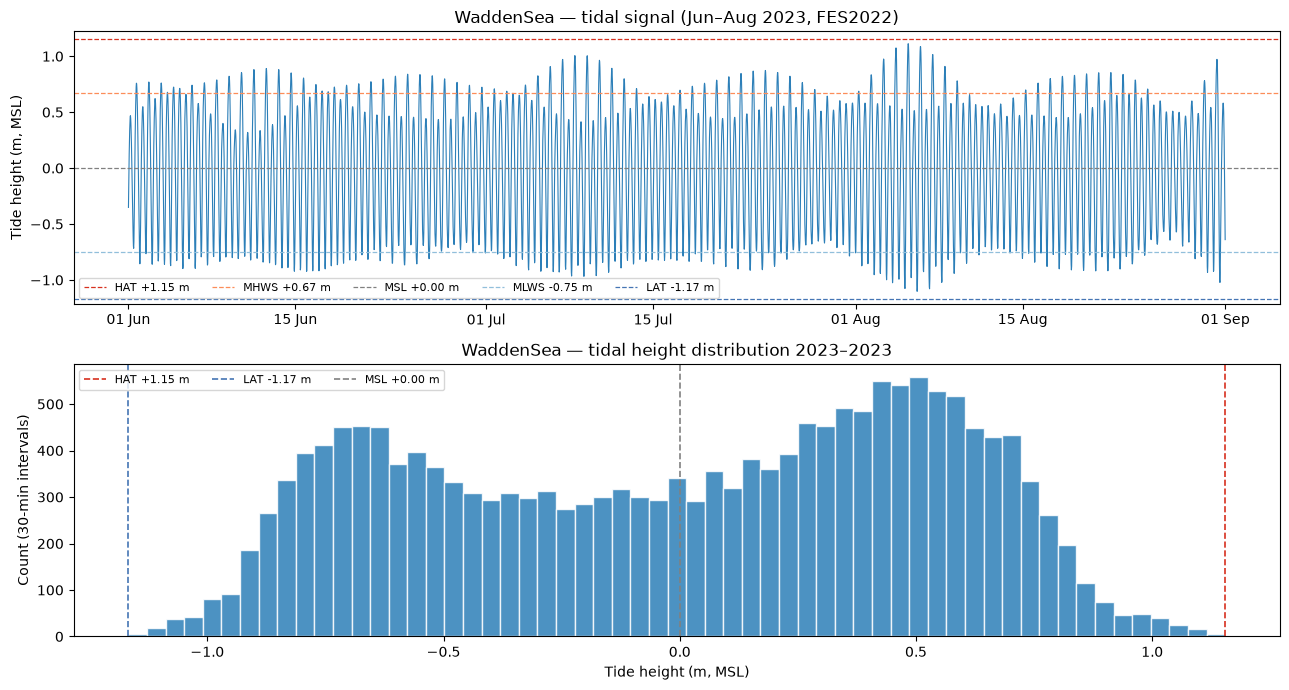

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7))

# Top panel: 3-month excerpt to show the spring-neap cycle
sample = heights.loc["2023-06-01":"2023-08-31"]
ax1.plot(sample.index, sample.values, lw=0.8, color="#2c7fb8")
for val, col, lbl in [(hat, "#d7301f", "HAT"), (mhws, "#fc8d59", "MHWS"),
                      (mean, "grey", "MSL"), (mlws, "#91bfdb", "MLWS"),
                      (lat_, "#4575b4", "LAT")]:
    ax1.axhline(val, ls="--", lw=0.9, color=col, label=f"{lbl} {val:+.2f} m")
ax1.set_ylabel("Tide height (m, MSL)")
ax1.set_title(f"{SITE_NAME} — tidal signal (Jun–Aug 2023, FES2022)")
ax1.legend(fontsize=8, ncol=5)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

# Bottom panel: histogram of the full 30-min series
bins = np.linspace(lat_, hat, 60)
ax2.hist(heights.values, bins=bins, color="#2c7fb8", edgecolor="white", alpha=0.85)
for val, col, lbl in [(hat, "#d7301f", "HAT"), (lat_, "#4575b4", "LAT"),
                      (mean, "grey", "MSL")]:
    ax2.axvline(val, color=col, lw=1.2, ls="--", label=f"{lbl} {val:+.2f} m")
ax2.set_xlabel("Tide height (m, MSL)")
ax2.set_ylabel("Count (30-min intervals)")
ax2.set_title(f"{SITE_NAME} — tidal height distribution {START[:4]}–{END[:4]}")
ax2.legend(fontsize=8, ncol=3)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{SITE_NAME}_tidal_range.png", dpi=150, bbox_inches="tight")
plt.show()

> **Why the histogram matters.** In a perfect world, satellites would observe every tide
> height equally often. In practice, sun-synchronous orbits revisit at nearly fixed local
> times, so acquisitions cluster at certain phases of the tidal cycle. That mismatch —
> **tidal aliasing** — is the main reason a site can have plenty of scenes yet still be
> unsuitable for elevation mapping. The next sections overlay your actual scene dates on
> this reference signal.

## Step 4 - Satellite scenes

Now we ask Planetary Computer: *when did clear satellites actually fly over this
location?* `load_or_compute_scenes` runs a STAC search for each enabled sensor, filters
by your cloud ceiling, and attaches the **FES2022 tide height at acquisition time** to
every remaining scene.

This step downloads **metadata only** — timestamps, cloud cover, footprints — not the
multispectral pixels. That keeps the notebook fast and makes it safe to explore many
date ranges and sensor combinations. The actual image download happens on pages 5–6.

Each row in the cached table is one scene: sensor name, acquisition time, cloud cover,
and modelled tide height. The **monthly count plot** below shows revisit density: flat
lines mean few passes; spikes mean many scenes in one month (often after enabling a
second Landsat platform or Sentinel-2). Gaps in the monthly record are normal — winter
cloud, orbit gaps, or scenes filtered out by `MAX_CLOUD`.

If a sensor returns zero scenes, check coordinates (are you over land or open ocean?),
widen `START`/`END`, or raise `MAX_CLOUD`. Change sensors and set `OVERWRITE = True`
to refresh the cache.

In [11]:
# Query PC for scene metadata and attach a tide height to each scene timestamp
scenes_df = load_or_compute_scenes(
    lon=LON, lat=LAT,
    start=START, end=END,
    site_name=SITE_NAME,
    tide_model=TIDE_MODEL,
    tide_dir=TIDE_DIR,
    max_cloud=MAX_CLOUD,
    sensors=SENSORS,
    overwrite=OVERWRITE,
)

# Ensure 'time' is a column (cache may return it as an index)
if "time" not in scenes_df.columns:
    scenes_df = scenes_df.reset_index()

print(f"\nScene counts at {SITE_NAME} (cloud < {MAX_CLOUD}%)")
if scenes_df.empty:
    print("  No scenes found — widen dates, raise MAX_CLOUD, or check coordinates.")
else:
    print(scenes_df.groupby("sensor").size().rename("total").to_frame().to_string())
    missing = set(SENSORS) - set(scenes_df["sensor"].unique())
    if missing:
        print(f"\n  No scenes for: {', '.join(sorted(missing))}")
        print("  (Normal for short windows or strict cloud limits.)")

  Loaded from cache ← cache/scenes_WaddenSea_s2-l8-l9_2023-01-01_2023-12-31.parquet  (42 rows)

Scene counts at WaddenSea (cloud < 80%)
            total
sensor           
Landsat 8       8
Landsat 9       8
Sentinel-2     26


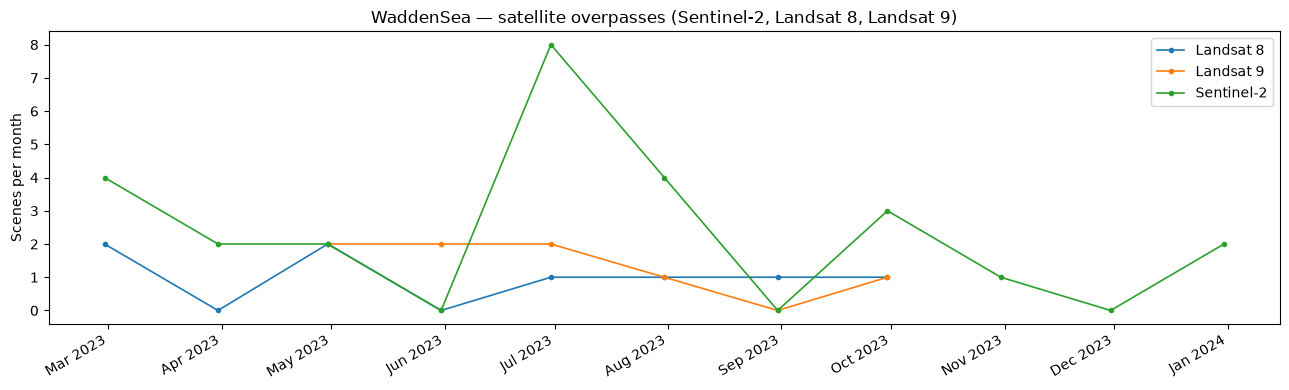

In [12]:
# Colour scheme shared across all plots in this notebook
colors = {"Sentinel-2": "#2ca02c", "Landsat 8": "#1f77b4", "Landsat 9": "#ff7f0e"}

fig, ax = plt.subplots(figsize=(13, 4))
if scenes_df.empty:
    ax.text(0.5, 0.5, "No scenes — adjust sensors, dates, or MAX_CLOUD",
            ha="center", va="center", transform=ax.transAxes)
else:
    # Resample to monthly count per sensor to show revisit density
    for sensor, grp in scenes_df.groupby("sensor"):
        monthly = grp.set_index("time").resample("ME").size()
        ax.plot(monthly.index, monthly.values, marker="o", ms=3, lw=1.2,
                label=sensor, color=colors.get(sensor, "grey"))
    ax.legend()
ax.set_ylabel("Scenes per month")
ax.set_title(f"{SITE_NAME} — satellite overpasses ({', '.join(SENSORS)})")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=30, ha="right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{SITE_NAME}_scene_counts.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 5 - Coverage statistics

The table below formalises what your eyes will check in the sampling plot. For each
sensor (and for all sensors combined), we compare the tide heights of **clear scenes**
against the full FES2022 series using the metrics from Bishop-Taylor et al. (2019) —
the same framework behind the DEA Intertidal product.

Intuition for each column:

| Column | Meaning | Good value |
|---|---|---|
| `observed_count` | Number of clear scenes contributing | ≥ 20 |
| `observed_range` | Spread from lowest to highest observed tide (m) | close to full HAT–LAT |
| `tot` | Fraction of the HAT–LAT range that scenes actually span | ≥ 0.8 |
| `hot` | How well the **upper** part of the range is sampled (high tides) | ≥ 0.5 |
| `lot` | How well the **lower** part is sampled (low tides) | ≥ 0.5 |

**TOT** near 1.0 means satellite passes reached almost the full vertical extent of the
tide curve. **HOT** and **LOT** penalise clustering: you can have a wide observed range
but still miss extremes if all scenes sit in the middle of the curve. **`observed_count`**
matters because the elevation fit on page 6 stacks many noisy wet/dry decisions — too
few scenes and per-pixel estimates become unstable even when TOT looks acceptable.

The CSV saved to `outputs/` is useful if you compare several sites or time windows in
a group project.

In [13]:
from cache_utils import tidal_coverage_stats

# Only use scenes that pass the cloud-cover filter
clear_mask = scenes_df["cloud_cover"].fillna(100) < MAX_CLOUD
MIN_CLEAR = 3  # minimum scenes needed to compute meaningful stats

stats_rows = []

# Compute stats per sensor
for sensor in scenes_df["sensor"].unique():
    mask = (scenes_df["sensor"] == sensor) & clear_mask
    sub = scenes_df.loc[mask, "tide_height"].dropna()
    stats = tidal_coverage_stats(sub.values, heights.values, min_observations=MIN_CLEAR)
    if stats is None:
        print(f"  {sensor}: only {len(sub)} clear scene(s) (need ≥{MIN_CLEAR}) — skipping")
        continue
    stats_rows.append({"sensor": sensor, **stats})

# Also compute stats for all sensors combined
all_clear = scenes_df.loc[clear_mask, "tide_height"].dropna()
combined = tidal_coverage_stats(all_clear.values, heights.values, min_observations=MIN_CLEAR)
if combined is not None:
    stats_rows.append({"sensor": "ALL (combined)", **combined})

if not stats_rows:
    raise ValueError(
        f"No stats — fewer than {MIN_CLEAR} clear scenes. "
        f"Enable more sensors, extend START/END, or raise MAX_CLOUD."
    )

stats_df = pd.DataFrame(stats_rows).set_index("sensor")
cols = [c for c in ["observed_count", "observed_range", "tot", "hot", "lot"]
        if c in stats_df.columns]
print(f"\nTidal coverage statistics — {SITE_NAME}")
print(stats_df[cols].round(3).to_string())

# Save as CSV for reference
stats_df[cols].round(3).to_csv(OUTPUT_DIR / f"{SITE_NAME}_coverage_stats.csv")


Tidal coverage statistics — WaddenSea
                observed_count  observed_range    tot    hot    lot
sensor                                                             
Landsat 8                    8           1.744  0.751  0.936  0.815
Sentinel-2                  26           1.304  0.562  0.855  0.707
Landsat 9                    8           1.791  0.771  0.909  0.862
ALL (combined)              42           1.853  0.798  0.936  0.862


## Step 6 - Sampling plot

This is the most important figure in the notebook. Read it as a direct overlay of
**when satellites looked** (coloured dots) on **what the sea was doing** (grey curve).

- The **grey line** is the continuous FES2022 tide — the full astronomical signal.
- Each **dot** is one clear scene, coloured by sensor, positioned at its acquisition
  time (horizontal) and modelled tide height (vertical).
- **Dashed red/blue** lines mark **HAT** and **LAT** — the model extremes in your window.
- **Dotted** lines at **HOT** and **LOT** mark the highest and lowest tide heights
  actually observed by any clear scene.
- **Shaded bands** between HAT→HOT and LAT→LOT are the **offsets**: vertical slices of
  the tidal range that satellites never sampled.

Large offsets are a warning sign. Pixels whose crossover elevation falls inside an
unobserved band cannot be constrained by the waterline fit — they will be masked or
carry high uncertainty on page 6. A common fix is a **longer time window** (more years
so revisit phases drift through the cycle) or **adding Sentinel-2** to densify sampling
between Landsat passes.

Highest satellite observation (HOT): +1.006 m
Lowest  satellite observation (LOT): -0.847 m
Offset HAT → HOT : 0.149 m  (6.4% of range)
Offset LAT → LOT : 0.319 m  (13.8% of range)


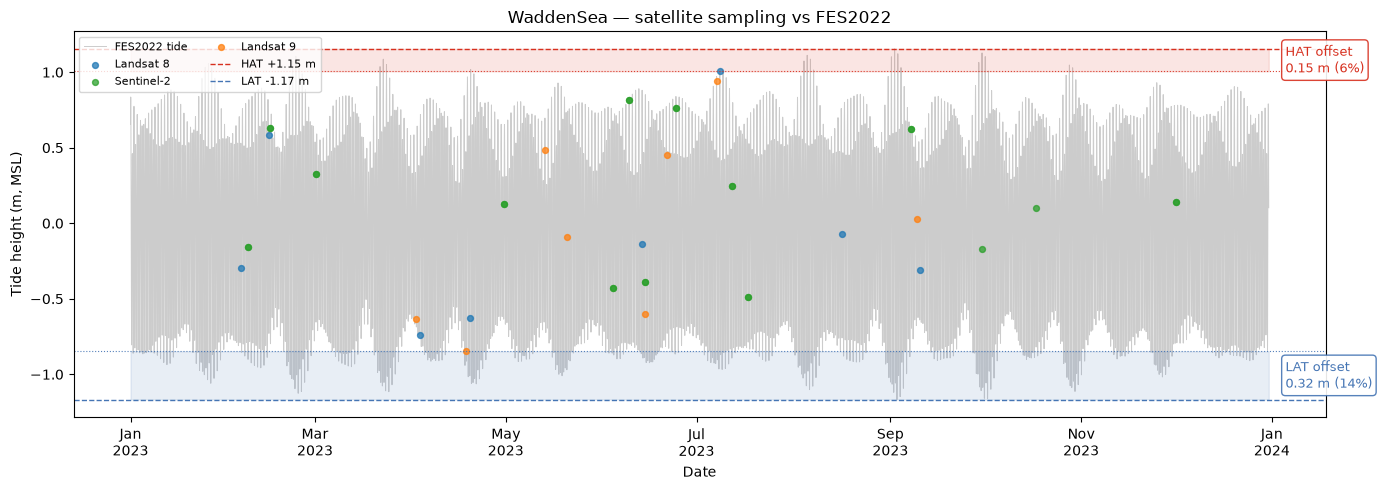

In [14]:
obs = scenes_df.loc[clear_mask, "tide_height"].dropna()
if len(obs) < 1:
    raise ValueError("No clear scenes with tide heights — check the scene step above.")

hot = float(obs.max())   # highest tide actually observed by a satellite
lot = float(obs.min())   # lowest tide actually observed
tr  = float(hat - lat_)  # full astronomical tidal range

# How much of the high/low extremes were never imaged?
offset_high_m   = hat  - hot
offset_low_m    = lot  - lat_
offset_high_pct = offset_high_m / tr if tr > 0 else float("nan")
offset_low_pct  = offset_low_m  / tr if tr > 0 else float("nan")

print(f"Highest satellite observation (HOT): {hot:+.3f} m")
print(f"Lowest  satellite observation (LOT): {lot:+.3f} m")
print(f"Offset HAT → HOT : {offset_high_m:.3f} m  ({offset_high_pct:.1%} of range)")
print(f"Offset LAT → LOT : {offset_low_m:.3f} m  ({offset_low_pct:.1%} of range)")

fig, ax = plt.subplots(figsize=(14, 5))

# Background: full FES2022 tide signal
tide_ts = heights.copy()
tide_ts.index = pd.to_datetime(tide_ts.index, utc=True)
ax.plot(tide_ts.index, tide_ts.values, color="#cccccc", lw=0.7, zorder=0,
        label="FES2022 tide")

# Overlay satellite passes as dots at their tide height
for sensor in scenes_df["sensor"].unique():
    sub = scenes_df.loc[(scenes_df["sensor"] == sensor) & clear_mask]
    ax.scatter(sub["time"], sub["tide_height"], s=18, alpha=0.75,
               label=sensor, color=colors.get(sensor, "grey"), zorder=2)

# HAT/LAT reference lines (dashed) and HOT/LOT (dotted)
ax.axhline(hat,  color="#d7301f", lw=1.0, ls="--", label=f"HAT {hat:+.2f} m")
ax.axhline(lat_, color="#4575b4", lw=1.0, ls="--", label=f"LAT {lat_:+.2f} m")
ax.axhline(hot,  color="#d7301f", lw=0.8, ls=":",  alpha=0.9)
ax.axhline(lot,  color="#4575b4", lw=0.8, ls=":",  alpha=0.9)

# Shaded offset bands with annotation at the right edge
x_annot = tide_ts.index.max()
for y0, y1, col, txt in [
    (hot, hat,  "#d7301f", f"HAT offset\n{offset_high_m:.2f} m ({offset_high_pct:.0%})"),
    (lat_, lot, "#4575b4", f"LAT offset\n{offset_low_m:.2f} m ({offset_low_pct:.0%})"),
]:
    ax.fill_between(tide_ts.index, y0, y1, color=col, alpha=0.12, zorder=1)
    ax.annotate(
        txt,
        xy=(x_annot, (y0 + y1) / 2),
        xytext=(12, 0), textcoords="offset points",
        va="center", ha="left", fontsize=9, color=col,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=col, alpha=0.9),
    )

ax.set_xlabel("Date")
ax.set_ylabel("Tide height (m, MSL)")
ax.set_title(f"{SITE_NAME} — satellite sampling vs FES2022")
ax.legend(fontsize=8, ncol=2, loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{SITE_NAME}_tidal_sampling.png", dpi=150, bbox_inches="tight")
plt.show()

> **Reading this plot — four quick checks**
>
> 1. **Vertical span** — Do the dots cover most of the grey curve from bottom to top?
>    Clustering near mid-tide means the flats never see both very wet and very dry states.
> 2. **HAT offset** — Is the red shaded band small (< 10–15% of the tidal range)?
>    A large gap means you lack scenes near highest water; upper intertidal may be biased.
> 3. **LAT offset** — Same for the blue band at low tide; low flats may stay unmapped.
> 4. **Sensor mix** — With both Landsat and Sentinel-2 enabled, do the green dots fill
>    temporal gaps between blue/orange? Combined sensors often improve TOT even when
>    each platform alone looks marginal.
>
> If offsets stay large after extending to **3+ years**, consider a different AOI, a
> looser cloud filter for planning (then tighten on page 5), or accept that page 6 will
> only be reliable in the mid-intertidal zone.

## Step 7 - Summary

The cell below prints a **go / caution** verdict per sensor and overall, using the
rule-of-thumb thresholds from the introduction. Treat warnings as planning signals, not
hard stops — a site with LOW TOT can still produce useful maps in the mid-flat zone, but
you should know where to expect gaps before investing time in pages 5–6.

If the combined **ALL** row looks good, proceed to [4 · Validation](04_validation.ipynb)
(optional FES2022 check against a tide gauge) or straight to [5 · NDWI](05_ndwi.ipynb).
If not, adjust configuration, set `OVERWRITE = True`, and re-run from the tidal range
section before moving on.

In [15]:
print(f"{'='*60}")
print(f"TIDAL FEASIBILITY SUMMARY — {SITE_NAME}")
print(f"{'='*60}")
print(f"  Period  : {START} to {END}")
print(f"  Sensors : {', '.join(SENSORS)}")
print(f"  Range   : {hat-lat_:.2f} m  (LAT {lat_:+.2f} to HAT {hat:+.2f})")
print()

verdicts = []
for row in stats_rows:
    sensor = row["sensor"]
    n   = int(row.get("observed_count", 0))
    tot = row.get("tot", float("nan"))
    hot = row.get("hot", float("nan"))
    lot = row.get("lot", float("nan"))

    # Flag any metric that falls below the rule-of-thumb thresholds
    flags = []
    if n < 20:
        flags.append("FEW SCENES (<20) — elevation fit will be noisy")
    if not pd.isna(tot) and tot < 0.8:
        flags.append(f"LOW RANGE COVERAGE (TOT={tot:.2f})")
    if not pd.isna(hot) and hot < 0.5:
        flags.append(f"HIGH TIDES UNDERSAMPLED (HOT={hot:.2f})")
    if not pd.isna(lot) and lot < 0.5:
        flags.append(f"LOW TIDES UNDERSAMPLED (LOT={lot:.2f})")

    status = "OK" if not flags else "WARNING"
    if sensor == "ALL (combined)":
        verdicts.append(status)  # used for the overall go/no-go line below

    print(f"[{status}] {sensor}  (n={n})")
    if not pd.isna(tot):
        print(f"  TOT={tot:.2f}  HOT={hot:.2f}  LOT={lot:.2f}")
    for f in flags:
        print(f"  ⚠  {f}")
    print()

if verdicts:
    print("=" * 60)
    if verdicts[0] == "OK":
        print("OVERALL: GOOD — proceed to page 5 (NDWI) or page 6 (elevation).")
    else:
        print("OVERALL: CAUTION — mapping may work but expect gaps or noise.")
        print("  Try: longer dates, enable Sentinel-2, or raise MAX_CLOUD.")
    print("=" * 60)

TIDAL FEASIBILITY SUMMARY — WaddenSea
  Period  : 2023-01-01 to 2023-12-31
  Sensors : Sentinel-2, Landsat 8, Landsat 9
  Range   : 2.32 m  (LAT -1.17 to HAT +1.15)

[WARNING] Landsat 8  (n=8)
  TOT=0.75  HOT=0.94  LOT=0.82
  ⚠  FEW SCENES (<20) — elevation fit will be noisy
  ⚠  LOW RANGE COVERAGE (TOT=0.75)

[WARNING] Sentinel-2  (n=26)
  TOT=0.56  HOT=0.85  LOT=0.71
  ⚠  LOW RANGE COVERAGE (TOT=0.56)

[WARNING] Landsat 9  (n=8)
  TOT=0.77  HOT=0.91  LOT=0.86
  ⚠  FEW SCENES (<20) — elevation fit will be noisy
  ⚠  LOW RANGE COVERAGE (TOT=0.77)

[WARNING] ALL (combined)  (n=42)
  TOT=0.80  HOT=0.94  LOT=0.86
  ⚠  LOW RANGE COVERAGE (TOT=0.80)

OVERALL: CAUTION — mapping may work but expect gaps or noise.
  Try: longer dates, enable Sentinel-2, or raise MAX_CLOUD.


---

:::{dropdown} About the cache

Expensive steps write Parquet files under `cache/`:

```
cache/
  tides_<site>_<start>_<end>.parquet            ← 30-min FES2022 series
  scenes_<site>_<sensors>_<start>_<end>.parquet ← STAC metadata + tide tags
```

Set `OVERWRITE = True` whenever you change coordinates, dates, or sensor toggles.
You can safely delete the whole `cache/` folder — it is rebuilt on the next run.
Do **not** commit it to git (large, site-specific).

The validation notebook (page 4) reuses the tide cache if site and dates match.
:::

**Next:** [4 · Validation](04_validation.ipynb) (optional) or [5 · NDWI](05_ndwi.ipynb)